In [1]:
!pip install transformers==4.28.0
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 61.5 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.20.0
    Uninstalling transformers-4.20.0:
      Successfully uninstalled transformers-4.20.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 12.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 17.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 23.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 19.3 MB/s eta 0:00:00


In [2]:
import re
import string
import pandas as pd
import tensorflow as tf

In [3]:
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification, Trainer, TrainingArguments
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer ,  AutoModelForSequenceClassification
from transformers import XLMRobertaTokenizer, BertForSequenceClassification, AdamW, get_linear_schedule_with_warmup, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [4]:
train = pd.read_excel("/content/offtrain.xlsx")
validation = pd.read_excel("/content/offval.xlsx")
test = pd.read_excel("/content/offtest.xlsx")

In [5]:
import datasets
import pandas as pd
from datasets import Dataset, DatasetDict

train_df = pd.DataFrame({
     "text" : train["text"],
     "labels" : train['label']

})
val_df = pd.DataFrame({
     "text" : validation["text"],
     "labels" : validation['label']

})

test_df = pd.DataFrame({
     "text" : test["text"],
     "labels" : test['label']

})

train_dataset = Dataset.from_dict(train_df)
val_dataset = Dataset.from_dict(val_df)
test_dataset = Dataset.from_dict(test_df)
dataset = datasets.DatasetDict({"train":train_dataset,"validation":val_dataset,"test":test_dataset})

In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 5475
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 609
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 1521
    })
})

In [7]:
dataset.num_rows

{'train': 5475, 'validation': 609, 'test': 1521}

In [8]:
dataset['train'][0]

{'text': 'دن لعنت گشتی گروپ ', 'labels': 1}

#Hyperparameters

In [9]:
num_epoch = 10
sq_len = 128
batch_size = 32
lr_rate = 1e-5
epsilon = 1e-8
hidden_dropout = 0.01
warmup_ratio = 0.01
weight_decay = 0.01

In [10]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Hate-speech-CNERG/urdu-abusive-MuRIL")

def encode_batch(batch):
  """Encodes a batch of input data using the model tokenizer."""
  return tokenizer(batch["text"], max_length=sq_len, truncation=True, padding="max_length")

# Encode the input data
dataset = dataset.map(encode_batch, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/5475 [00:00<?, ? examples/s]

Map:   0%|          | 0/609 [00:00<?, ? examples/s]

Map:   0%|          | 0/1521 [00:00<?, ? examples/s]

In [11]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5475
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 609
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1521
    })
})

Now we're ready to train our model...

## Training

We use a pre-trained RoBERTa model from HuggingFace. We use `RobertaModelWithHeads`, a class unique to `adapter-transformers`, which allows us to add and configure prediction heads in a flexibler way.

In [12]:
from transformers import AutoConfig
configuration = AutoConfig.from_pretrained('Hate-speech-CNERG/urdu-abusive-MuRIL', num_labels=2)
configuration.hidden_dropout_prob = hidden_dropout
model = BertForSequenceClassification.from_pretrained('Hate-speech-CNERG/urdu-abusive-MuRIL', config=configuration)

config.json:   0%|          | 0.00/657 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/950M [00:00<?, ?B/s]

In [13]:
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Number of trainable parameters:", num_trainable_params)

Number of trainable parameters: 237557762


In [14]:
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [15]:
# Define the function to compute the metrics during evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support,precision_score,recall_score,confusion_matrix
import time
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    precision = precision_score(labels, preds, average='macro',zero_division=0)
    recall = recall_score(labels, preds, average='macro',zero_division=0)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall, 'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}



In [16]:
optimizer = AdamW(model.parameters(), lr=lr_rate, eps=epsilon)
total_steps = len(dataset["train"]) * num_epoch
warmup_steps = int(total_steps * warmup_ratio)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

# optimizer = AdamW(model.parameters(), lr=2e-5,eps = 1e-8)
# scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=500, num_training_steps=len(dataset["train"])*10)


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [17]:
from datetime import datetime
import pandas as pd

# Create empty lists to store results
epoch_list = []
training_loss_list = []
validation_loss_list = []
training_time_list = []
validation_time_list = []
validation_accuracy_list = []
validation_f1_list = []

test_tp_list = []
test_tn_list = []
test_fp_list = []
test_fn_list = []

test_accuracy_list = []
test_f1_list = []
test_precision_list = []
test_recall_list = []
# Define the trainer Arguments
training_args = TrainingArguments(
          output_dir='./results',
          overwrite_output_dir='True',
          num_train_epochs=1,
          per_device_train_batch_size=batch_size,
          per_device_eval_batch_size=batch_size,
          warmup_ratio=warmup_ratio,
          weight_decay=weight_decay,
          logging_dir='./logs',
          logging_steps=100,
          save_strategy='no',
          evaluation_strategy='no',
          load_best_model_at_end=True,
          metric_for_best_model='accuracy',
          greater_is_better=True,
          # learning_rate = lr_rate,
          # adam_epsilon = epsilon,

    )

train_epoch = num_epoch
# Train the model and track the metrics after each epoch
for epoch in range(train_epoch):


    # Define the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset["train"],
        eval_dataset=dataset["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        # optimizers=(optimizer, None)
    )


    # Train the model for one epoch
    start_time = datetime.now()
    train_result = trainer.train()
    end_time = datetime.now()

    # Perform optimization steps
    optimizer.step()
    scheduler.step()

    # Clear gradients
    optimizer.zero_grad()

    # Perform evaluation on the validation set
    validation_result = trainer.evaluate(eval_dataset=dataset["validation"])

    # Perform evaluation on the test set
    test_result = trainer.evaluate(eval_dataset=dataset["test"])

    # optimizer.step()
    # scheduler.step()

    # Extract the desired information
    training_loss = train_result.training_loss
    validation_loss = validation_result["eval_loss"]

    validation_time = validation_result["eval_runtime"]
    training_time = train_result.metrics["train_runtime"]

    validation_accuracy = validation_result["eval_accuracy"]
    validation_f1 = validation_result["eval_f1"]


    test_accuracy = test_result["eval_accuracy"]
    test_f1 = test_result["eval_f1"]
    test_precision = test_result["eval_precision"]
    test_recall = test_result["eval_recall"]

    test_tp = test_result["eval_tp"]
    test_tn = test_result["eval_tn"]
    test_fp = test_result["eval_fp"]
    test_fn = test_result["eval_fn"]

    val_runtime_formatted = pd.to_datetime(validation_time, unit='s').strftime('%H:%M:%S')
    train_runtime_formatted = pd.to_datetime(training_time, unit='s').strftime('%H:%M:%S')

    # Append the metrics to the respective lists
    epoch_list.append(epoch + 1)
    training_loss_list.append(training_loss)
    validation_loss_list.append(validation_loss)

    validation_accuracy_list.append(validation_accuracy)
    validation_f1_list.append(validation_f1)

    training_time_list.append(train_runtime_formatted)
    validation_time_list.append(val_runtime_formatted)

    test_tp_list.append(test_tp)
    test_tn_list.append(test_tn)
    test_fp_list.append(test_fp)
    test_fn_list.append(test_fn)


    test_accuracy_list.append(test_accuracy)
    test_f1_list.append(test_f1)
    test_precision_list.append(test_precision)
    test_recall_list.append(test_recall)

# Create a DataFrame to store the results
train_df = pd.DataFrame({
    "Epoch": epoch_list,
    "Training Loss": training_loss_list,
    "Validation Loss": validation_loss_list,
    "Validation Accuracy": validation_accuracy_list,
    "Validation F1": validation_f1_list,
    "Training Time": training_time_list,
    "Validation Time": validation_time_list,
})

test_df = pd.DataFrame({
    "Epoch": epoch_list,
    "Test TP": test_tp_list,
    "Test TN": test_tn_list,
    "Test FP": test_fp_list,
    "Test FN": test_fn_list,
    "Test Accuracy": test_accuracy_list,
    "Test F1": test_f1_list,
    "Test Precision": test_precision_list,
    "Test Recall": test_recall_list,
})

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss
100,0.442800


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss
100,0.230100


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


...

Step,Training Loss
100,0.071200


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss
100,0.076400


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss
100,0.077100


In [18]:
train_df.head(10)

,Epoch,Training Loss,Validation Loss,Validation Accuracy,Validation F1,Training Time,Validation Time
0,1,0.407584,0.346077,0.862069,0.861836,00:00:31,00:00:01
1,2,0.255499,0.356567,0.847291,0.847157,00:00:29,00:00:01
2,3,0.255923,0.430571,0.862069,0.862039,00:00:30,00:00:01
3,4,0.223413,0.493722,0.837438,0.836868,00:00:30,00:00:01
4,5,0.179619,0.497596,0.855501,0.855329,00:00:30,00:00:01
5,6,0.164871,0.470714,0.860427,0.860425,00:00:29,00:00:01
6,7,0.140769,0.485835,0.862069,0.861985,00:00:30,00:00:01
7,8,0.141710,0.565762,0.853859,0.853859,00:00:30,00:00:01
8,9,0.137624,0.637953,0.852217,0.852216,00:00:30,00:00:01
9,10,0.123593,0.624373,0.850575,0.850534,00:00:30,00:00:01


In [19]:
test_df.head(10)

,Epoch,Test TP,Test TN,Test FP,Test FN,Test Accuracy,Test F1,Test Precision,Test Recall
0,1,604,693,67,157,0.852728,0.852222,0.857722,0.852767
1,2,602,694,66,159,0.852071,0.851528,0.857398,0.852111
2,3,616,674,86,145,0.848126,0.847905,0.850224,0.848152
3,4,673,629,131,88,0.856016,0.855895,0.857166,0.855997
4,5,657,641,119,104,0.853386,0.853370,0.853526,0.853379
5,6,645,662,98,116,0.859303,0.859286,0.859501,0.859311
6,7,665,641,119,96,0.858646,0.858610,0.858978,0.858636
7,8,632,670,90,129,0.856016,0.855926,0.856947,0.856033
8,9,629,666,94,132,0.851414,0.851326,0.852286,0.851430
9,10,627,680,80,134,0.859303,0.859132,0.861113,0.859326


In [20]:
train_df.to_excel("Train Muril-SL128-15 epochs,32BS-(1e-5)-0.05HD-0.06WR-0.01WD.xlsx")

In [21]:
test_df.to_excel("Test Muril-SL128-15 epcohs,32BS-(1e-5)-0.05HD-0.06WR-0.01WD.xlsx")

## SHAP

In [22]:
!pip install shap matplotlib

In [23]:
import shap
import matplotlib.pyplot as plt
import torch

/usr/local/lib/python3.10/dist-packages/shap/utils/_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
/usr/local/lib/python3.10/dist-packages/shap/utils/_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def delta_minimization_order(all_masks, max_swap_size=100, num_

In [24]:
import scipy as sp
import numpy as np
import torch
import shap

# Prediction function
def f(x):
    tv = torch.tensor(
        [
            tokenizer.encode(v, padding="max_length", max_length=128, truncation=True)
            for v in x
        ]
    ).cuda()
    outputs = model(tv)[0].detach().cpu().numpy()
    scores = (np.exp(outputs).T / np.exp(outputs).sum(-1)).T
    val = sp.special.logit(scores[:, 1])
    return val

# SHAP explainer
explainer = shap.Explainer(f, tokenizer)

In [25]:
test.head(100)

,text,label
0,نواز شریف نے ہمیشہ آئین اور قانون کا احترام کی...,0
1,لعنت ھو تم پر,1
2,ڈاکٹر طاہر صاحب سے مدد لی جائے تو اتنی پریشانی...,0
3,یہ ترجیحات ہیں سلیکٹڈ حکومت کی اور یہ سریسنس ہ...,1
4,مارے پاس پہلے ھی ہجڑانہ یوتھیانہ اور زنانہ واٸ...,1
...,...,...
95,لعنت تیری زندگانی پر اور سیاسی زندگی پر,1
96,لعنت بیشمار مودی کے یار پر,1
97,کاش دنیا جنگی ہتھیار بنانے کی بجائے انسانی فلا...,0
98,ھماری بلی ہمیں میاٶں,1


In [26]:
# Explanation of the model's predictions on the test dataset
shap_values = explainer(test['text'].values[69:71])  # instances which have labelled with 1

# Plot
shap.plots.text(shap_values)

Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from current font.
Matplotlib currently does not support Arabic natively.
Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from current font.


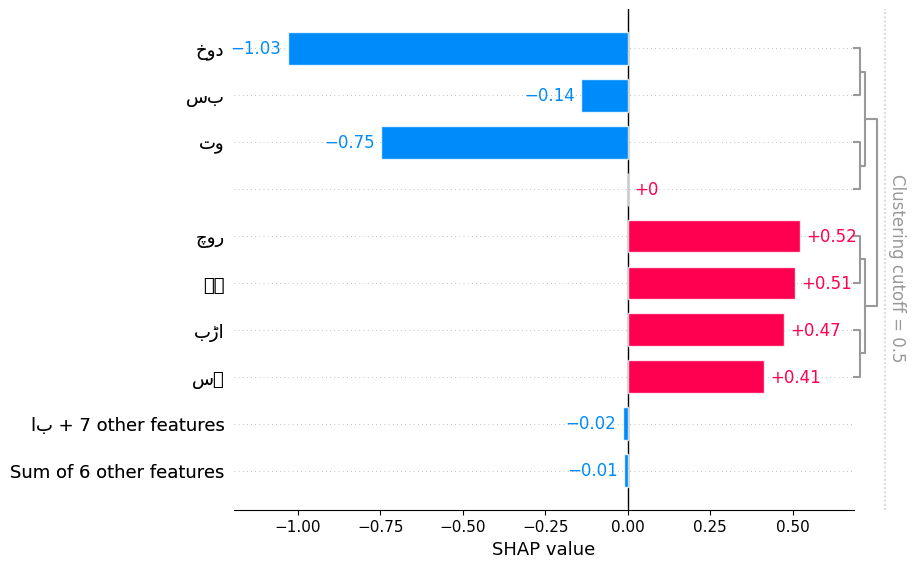

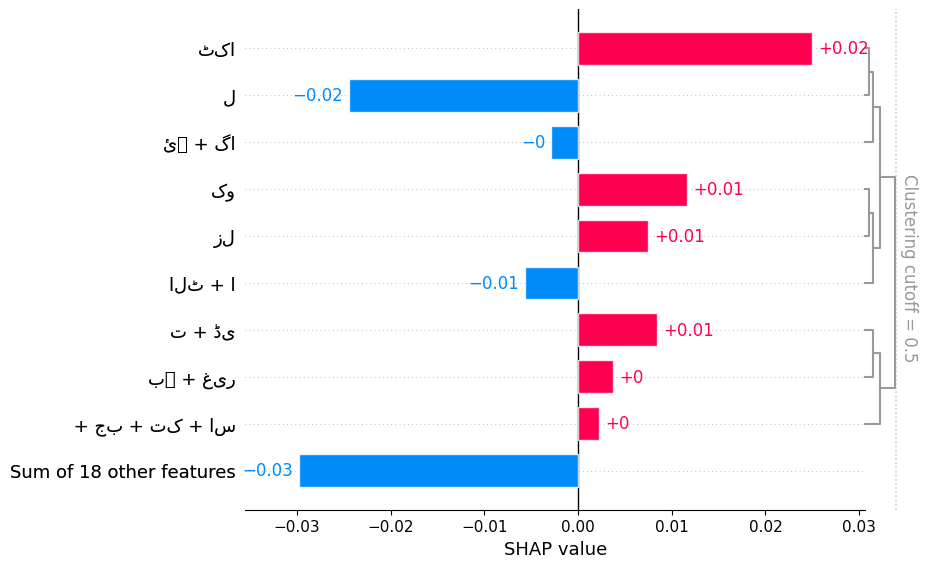

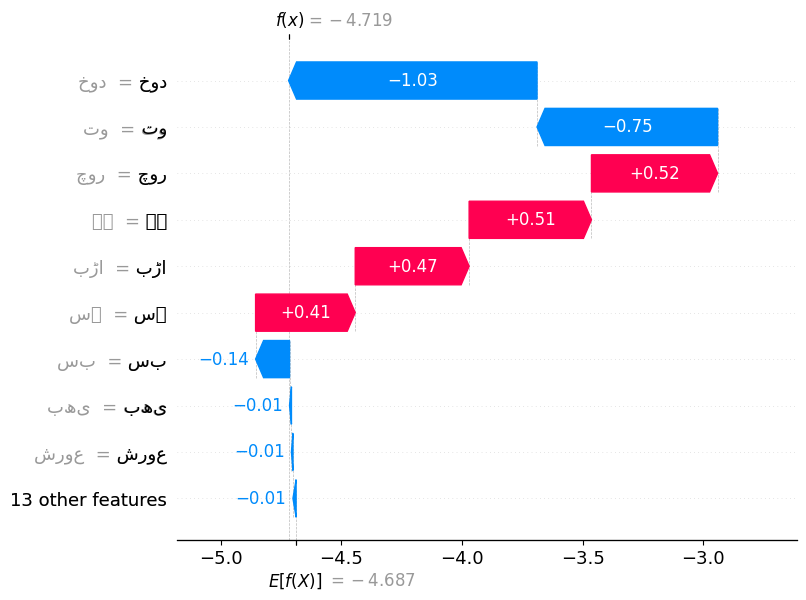

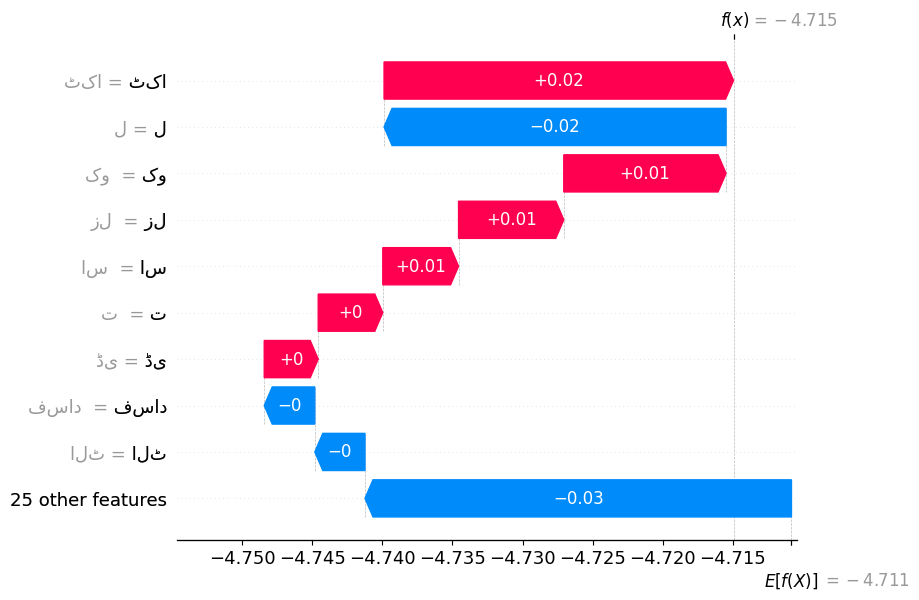

In [27]:
# Bar plot of Shap values
shap.plots.bar(shap_values[0]) # for instance 0 etc.
shap.plots.bar(shap_values[1])

# Waterfall plot of Shap values
shap.plots.waterfall(shap_values[0]) # for instance 0 etc.
shap.plots.waterfall(shap_values[1])

In [34]:
# Explanation of the model's predictions on the test dataset
shap_values = explainer(test['text'].values[75:77])  # instances which have labelled with 1

# Plot
shap.plots.text(shap_values)

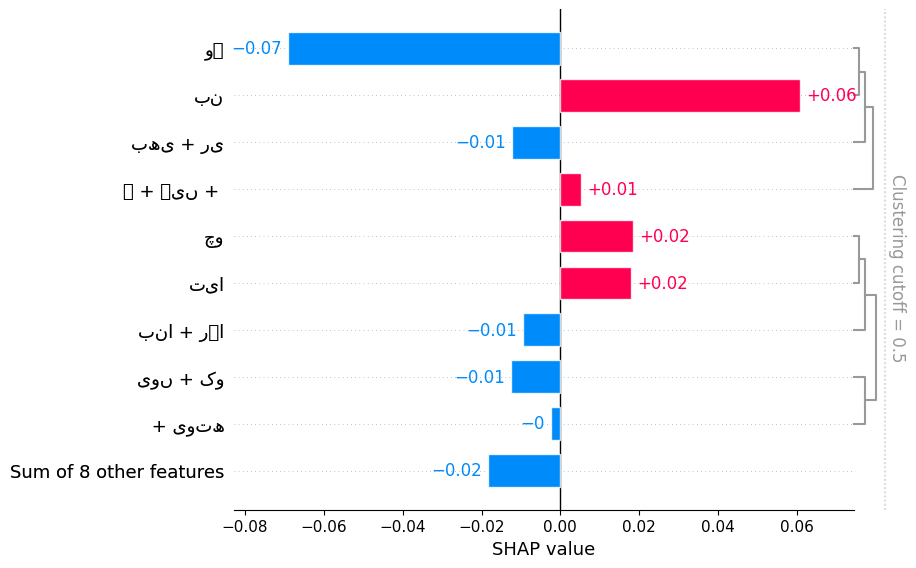

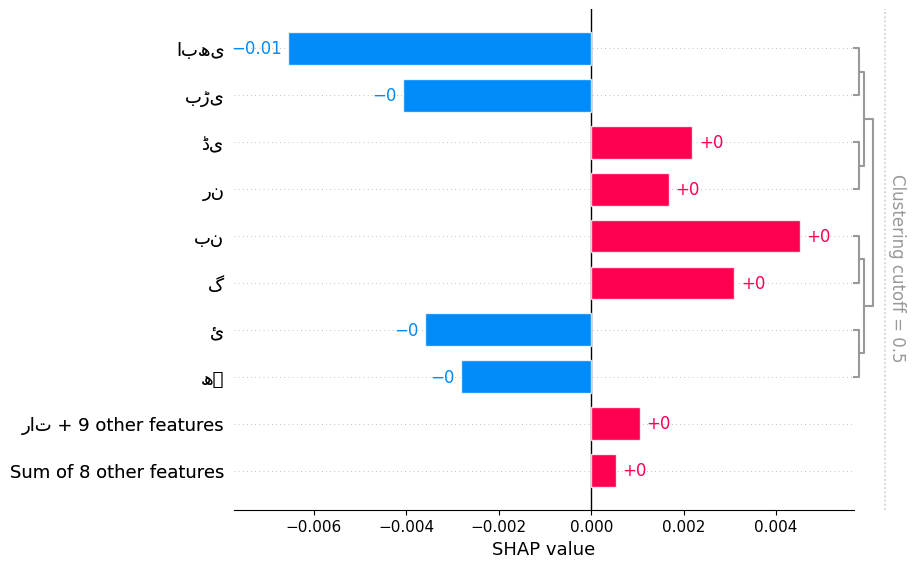

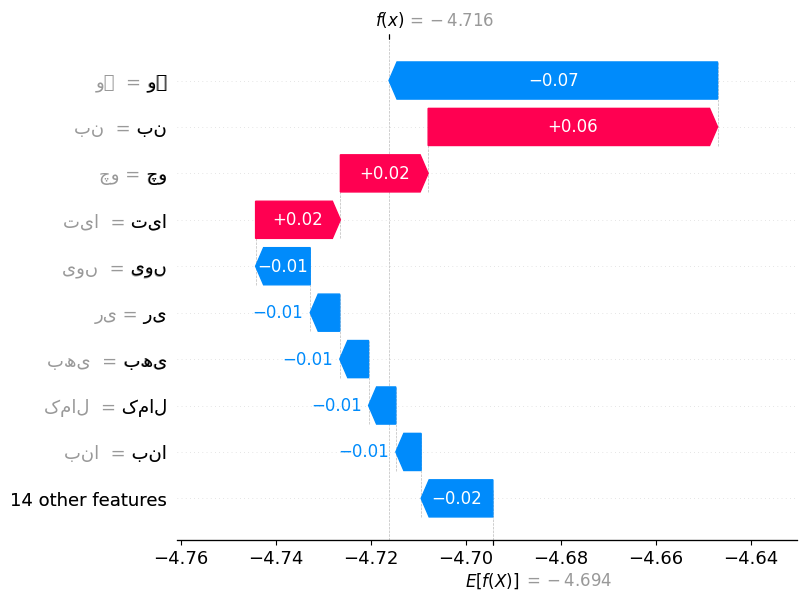

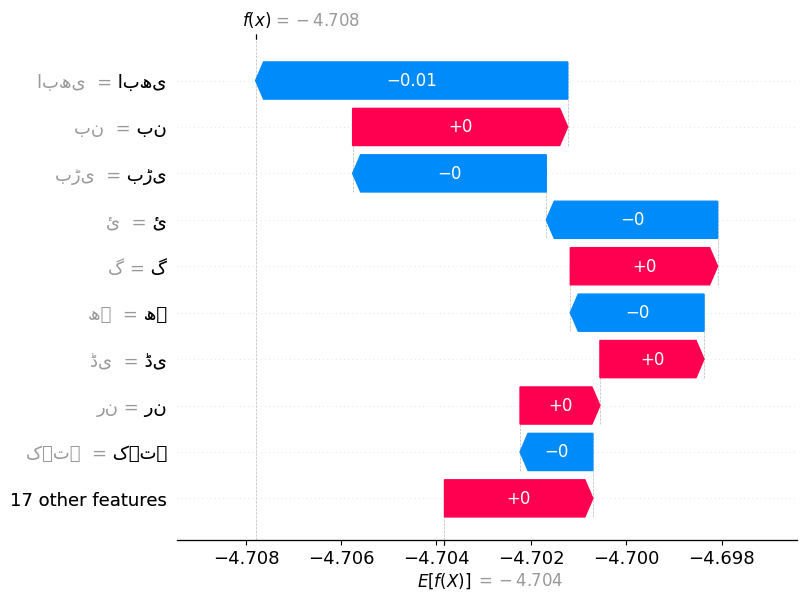

In [36]:
# Bar plot of Shap values
shap.plots.bar(shap_values[0]) # for instance 0 etc.
shap.plots.bar(shap_values[1])

# Waterfall plot of Shap values
shap.plots.waterfall(shap_values[0]) # for instance 0 etc.
shap.plots.waterfall(shap_values[1])

In [38]:
# Explanation of the model's predictions on the test dataset
shap_values = explainer(test['text'].values[26:28])  # instances which have labelled with 1

# Plot
shap.plots.text(shap_values)

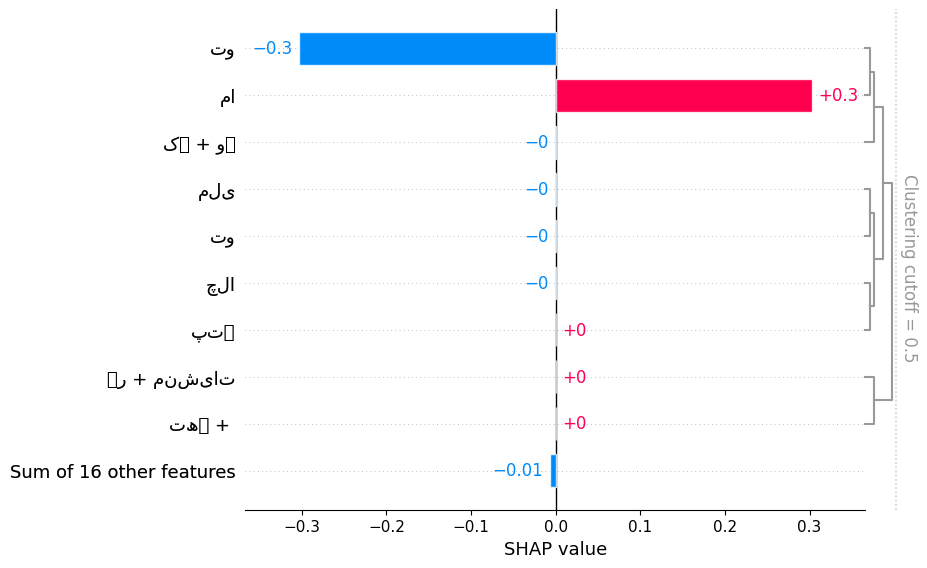

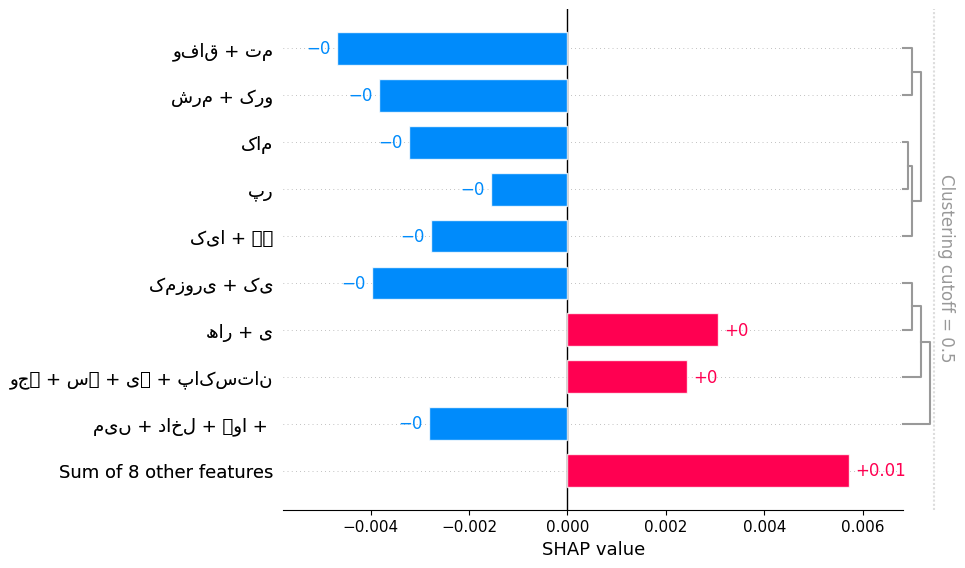

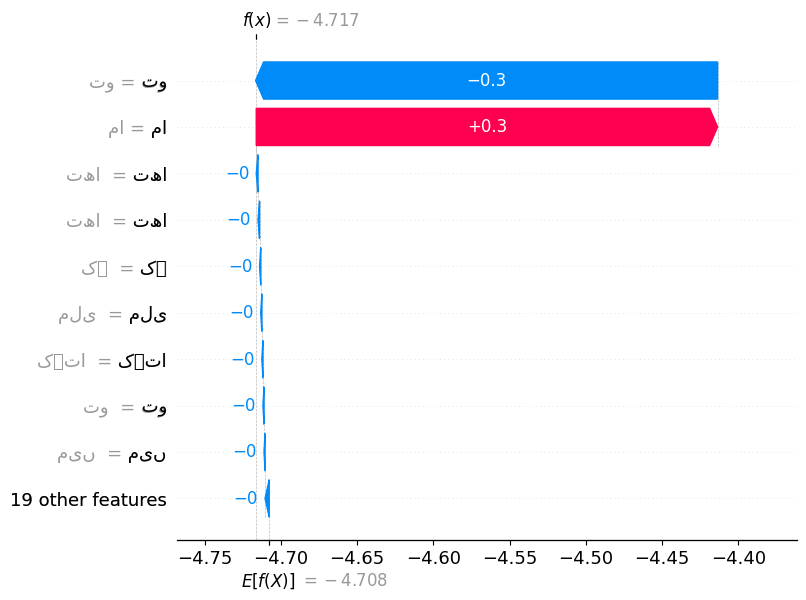

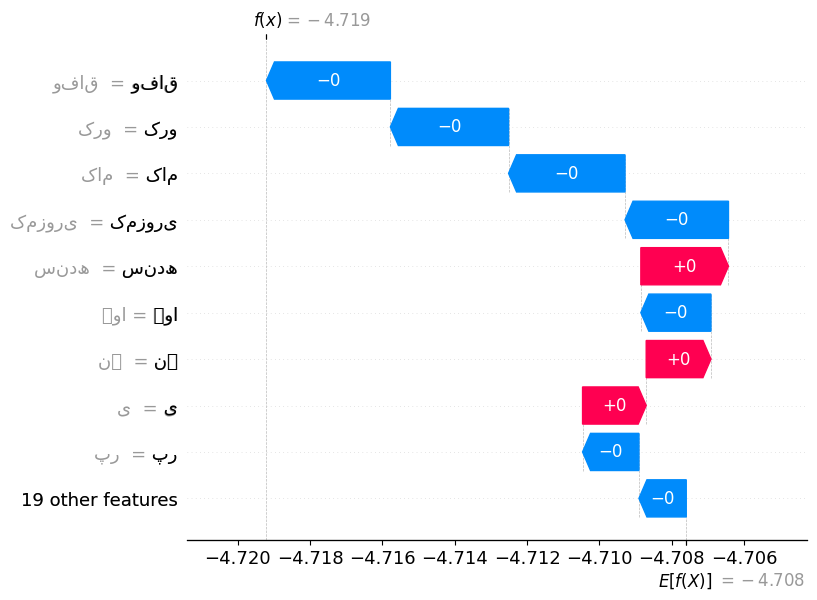

In [39]:
# Bar plot of Shap values
shap.plots.bar(shap_values[0]) # for instance 0 etc.
shap.plots.bar(shap_values[1])

# Waterfall plot of Shap values
shap.plots.waterfall(shap_values[0]) # for instance 0 etc.
shap.plots.waterfall(shap_values[1])

In [42]:
# Explanation of the model's predictions on the test dataset
shap_values = explainer(test['text'].values[36:38])  # instances which have labelled with 0

# Plot
shap.plots.text(shap_values)

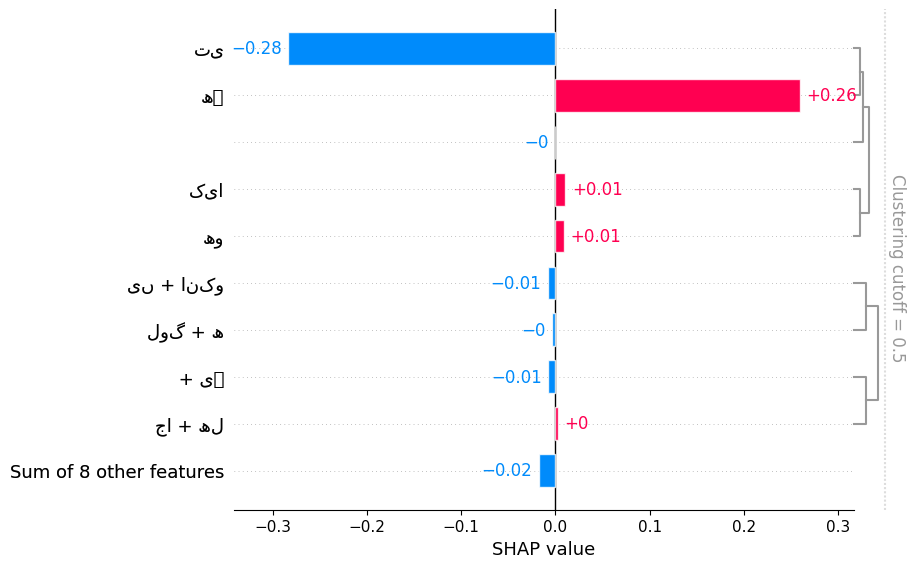

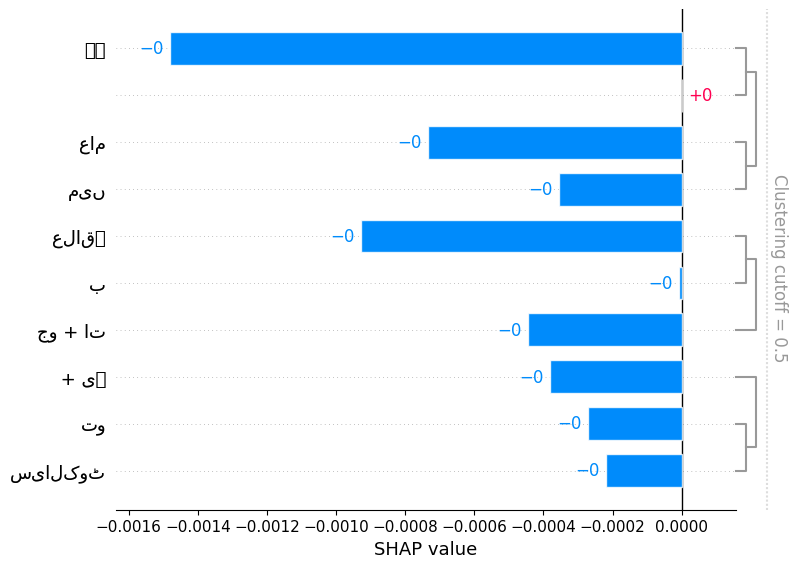

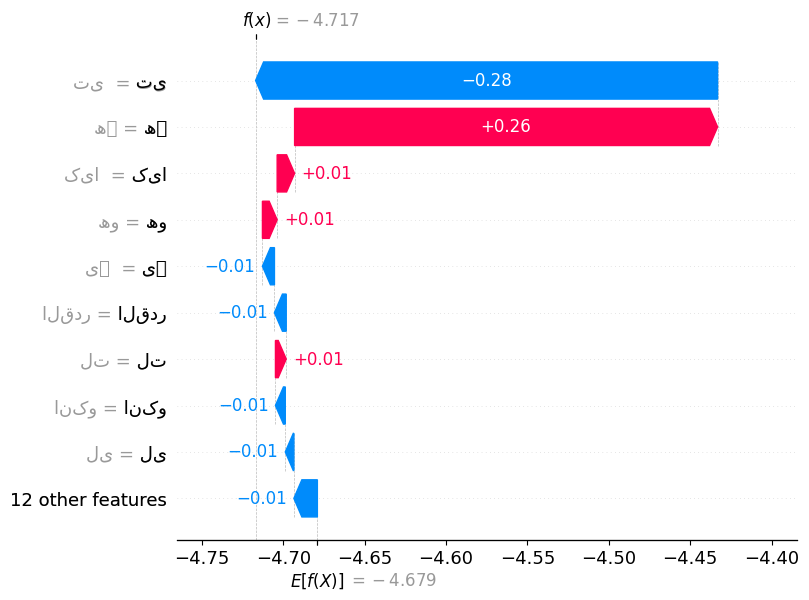

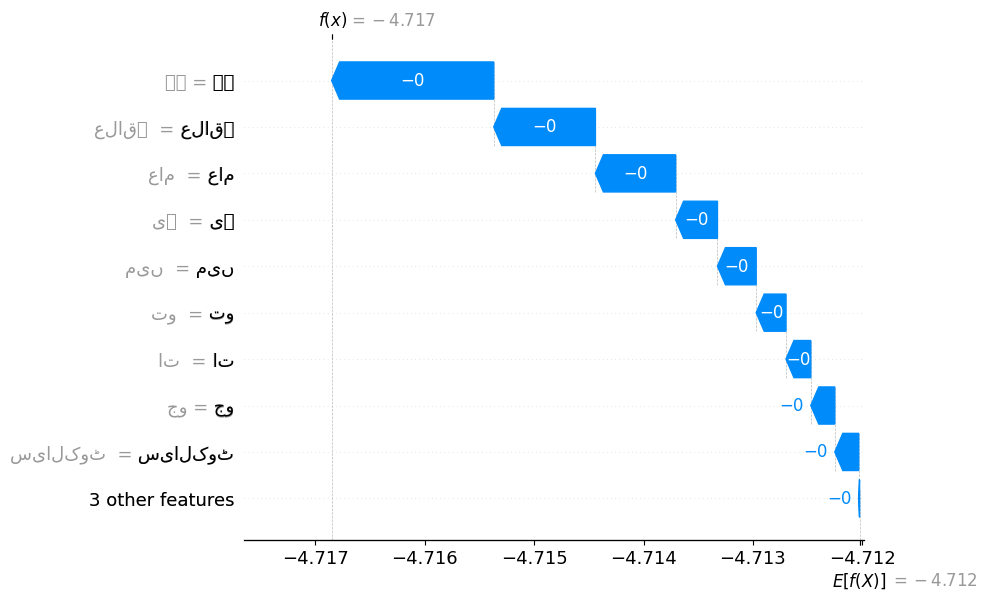

In [43]:
# Bar plot of Shap values
shap.plots.bar(shap_values[0]) # for instance 0 etc.
shap.plots.bar(shap_values[1])

# Waterfall plot of Shap values
shap.plots.waterfall(shap_values[0]) # for instance 0 etc.
shap.plots.waterfall(shap_values[1])

In [44]:
# Explanation of the model's predictions on the test dataset
shap_values = explainer(test['text'].values[43:45])  # instances which have labelled with 0

# Plot
shap.plots.text(shap_values)

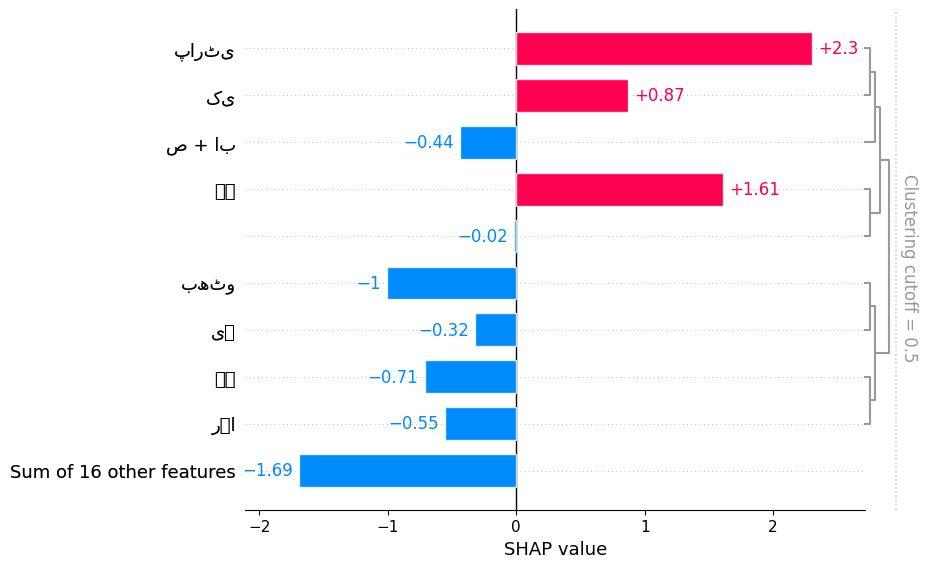

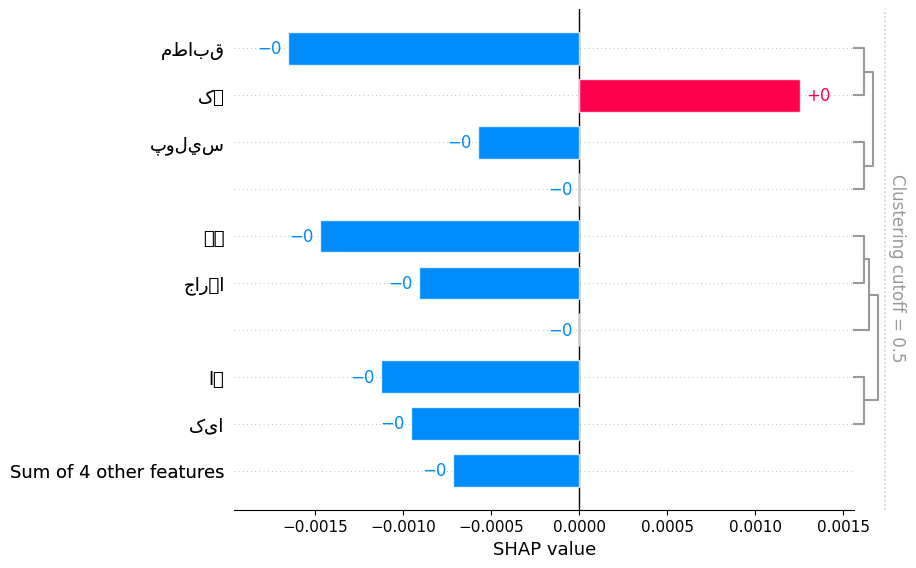

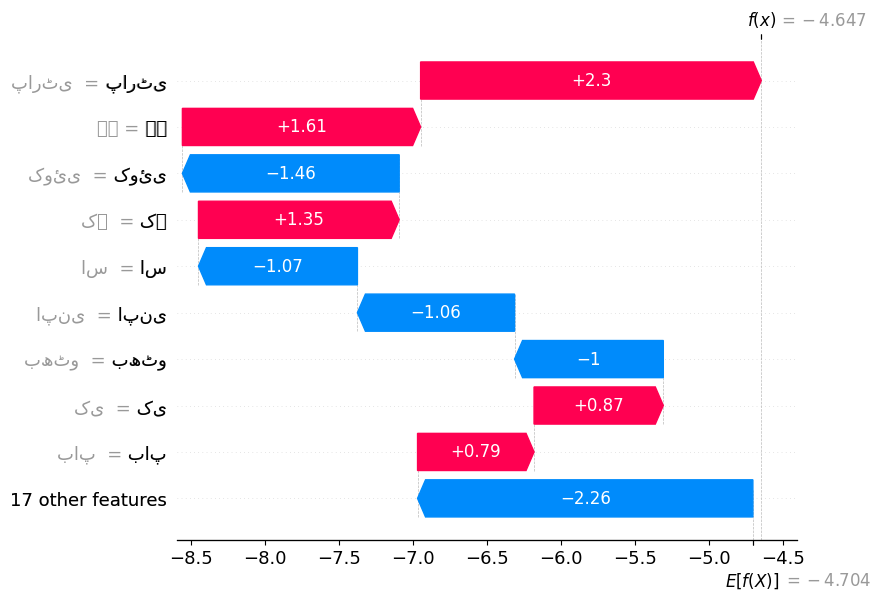

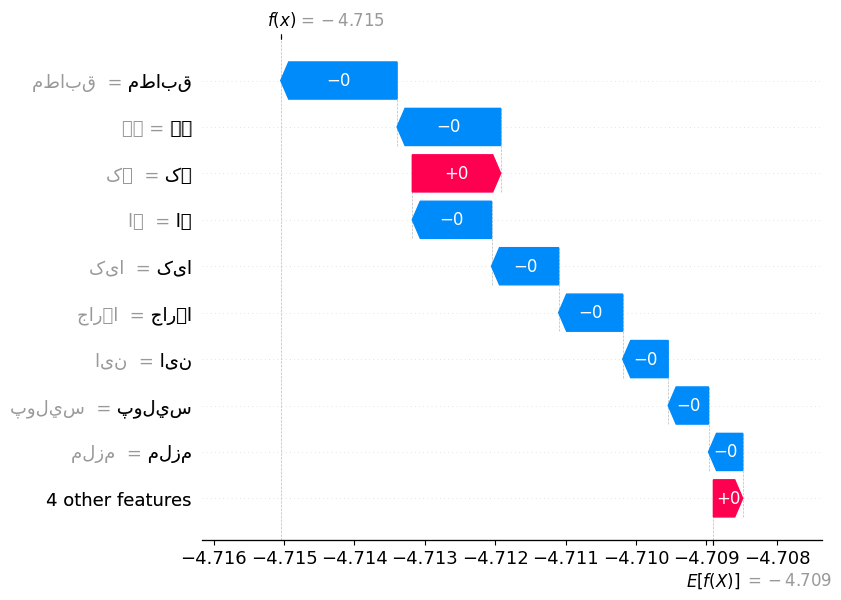

In [45]:
# Bar plot of Shap values
shap.plots.bar(shap_values[0]) # for instance 0 etc.
shap.plots.bar(shap_values[1])

# Waterfall plot of Shap values
shap.plots.waterfall(shap_values[0]) # for instance 0 etc.
shap.plots.waterfall(shap_values[1])

In [46]:
# Explanation of the model's predictions on the test dataset
shap_values = explainer(test['text'].values[84:86])  # instances which have labelled with 0

# Plot
shap.plots.text(shap_values)

Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from current font.
Matplotlib currently does not support Arabic natively.
Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from current font.


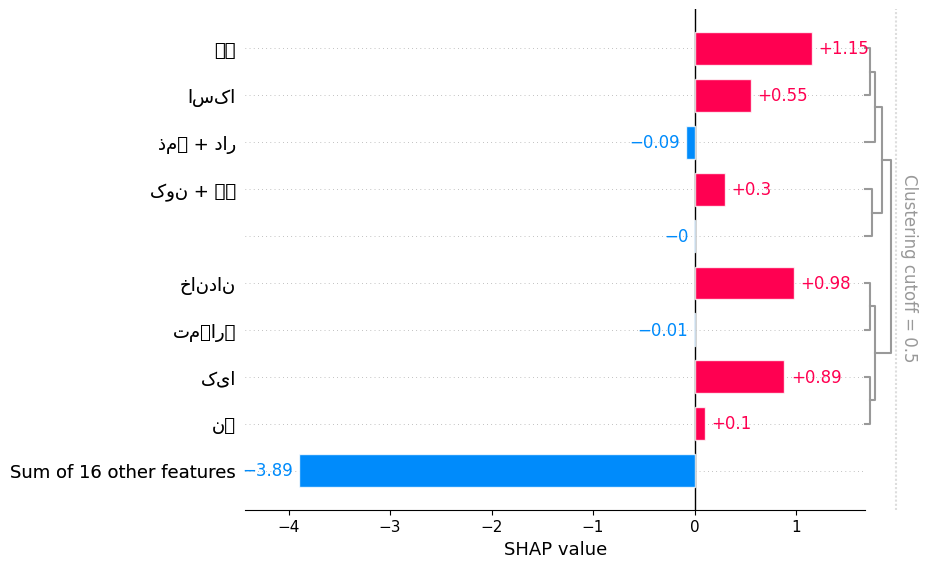

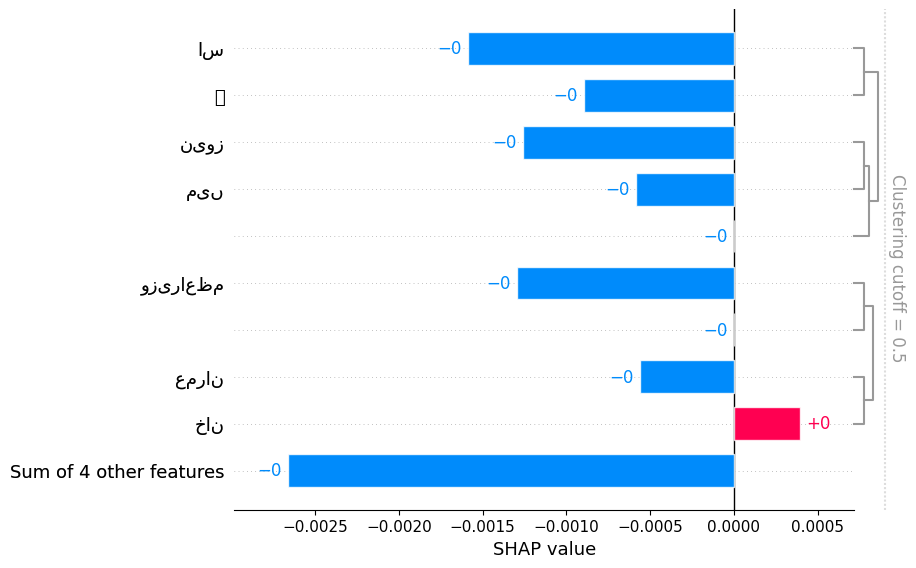

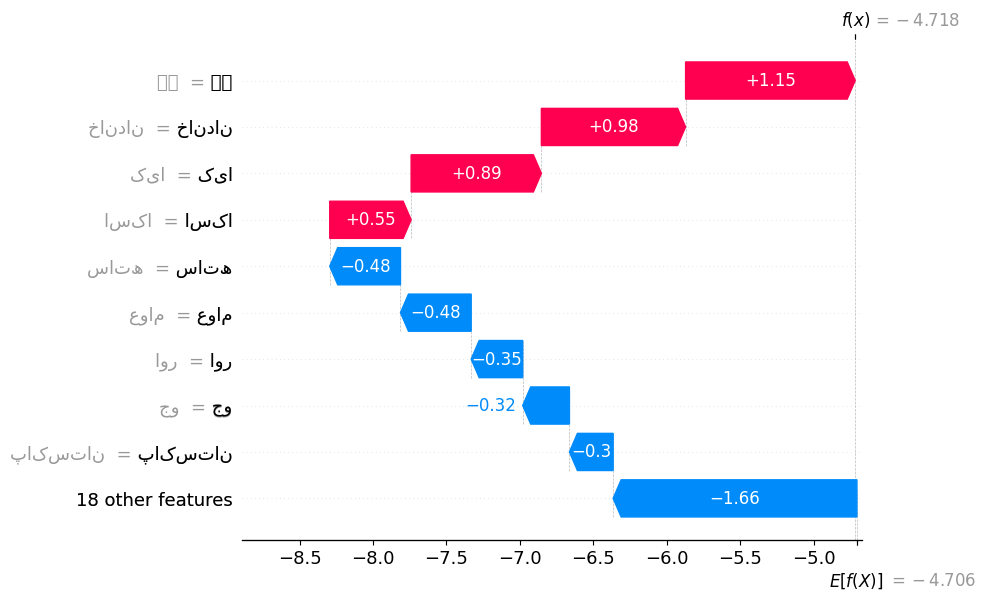

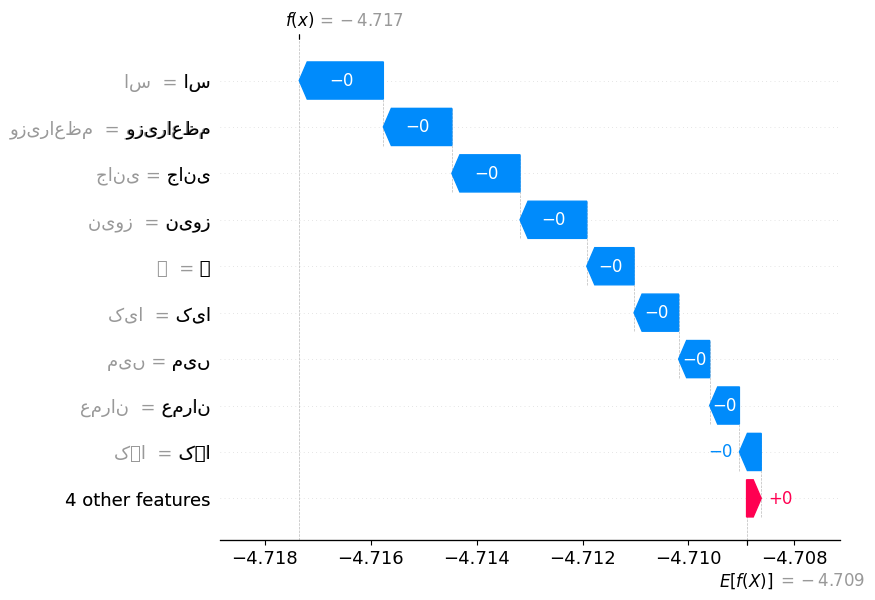

In [47]:
# Bar plot of Shap values
shap.plots.bar(shap_values[0]) # for instance 0 etc.
shap.plots.bar(shap_values[1])

# Waterfall plot of Shap values
shap.plots.waterfall(shap_values[0]) # for instance 0 etc.
shap.plots.waterfall(shap_values[1])